# Импорты и загрузка графов

In [4]:
import pandas as pd
import numpy as np
import json
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from pyvis.network import Network
from IPython.display import IFrame, display, HTML


# Настройка путей

In [5]:
PROJECT_ROOT = Path("SNA").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

GRAPH_NODES_PATH = PROCESSED_DIR / "graph_nodes_model_ready.parquet"
GRAPH_EDGES_PATH = PROCESSED_DIR / "graph_edges_model_ready.parquet"

GRAPH_NODES_CSV_PATH = PROCESSED_DIR / "graph_nodes_model_ready.csv"
GRAPH_EDGES_CSV_PATH = PROCESSED_DIR / "graph_edges_model_ready.csv"

VIS_DIR = PROCESSED_DIR / "graph_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

print(VIS_DIR)


/Users/gaperov/Documents/University/SNA/data/processed/graph_visualizations


# Функция безопасной загрузки

In [6]:
def load_table_flexible(parquet_path, csv_path=None):
    parquet_path = Path(parquet_path)

    if parquet_path.exists():
        return pd.read_parquet(parquet_path)

    if csv_path is not None:
        csv_path = Path(csv_path)
        if csv_path.exists():
            return pd.read_csv(csv_path)

    raise FileNotFoundError(f"Could not find {parquet_path} or {csv_path}")


In [7]:
graph_nodes = load_table_flexible(GRAPH_NODES_PATH, GRAPH_NODES_CSV_PATH)
graph_edges = load_table_flexible(GRAPH_EDGES_PATH, GRAPH_EDGES_CSV_PATH)

print("Nodes:", graph_nodes.shape)
print("Edges:", graph_edges.shape)

display(graph_nodes.tail())
display(graph_edges.head())


Nodes: (1007, 7)
Edges: (4741, 10)


,node_id,node_type,name,canonical_name,source_id,tournament_year,metadata_json
1002,team_tournament_3840790eec64,TeamTournament,Korea Republic 2022,team_tournament_3840790eec64,NaN,2022.0,"{""team_id"": ""team_3c6cfbc2415a"", ""team_norm"": ..."
1003,team_tournament_646c1bd4863a,TeamTournament,Portugal 2022,team_tournament_646c1bd4863a,NaN,2022.0,"{""team_id"": ""team_ae0eea6eb6d6"", ""team_norm"": ..."
1004,team_tournament_9d9629b9f049,TeamTournament,Ghana 2022,team_tournament_9d9629b9f049,NaN,2022.0,"{""team_id"": ""team_0e6049dbb2ce"", ""team_norm"": ..."
1005,team_tournament_b000942ef726,TeamTournament,Brazil 2022,team_tournament_b000942ef726,NaN,2022.0,"{""team_id"": ""team_6e5fa4d9c48c"", ""team_norm"": ..."
1006,team_tournament_b06be90e22cd,TeamTournament,Serbia 2022,team_tournament_b06be90e22cd,NaN,2022.0,"{""team_id"": ""team_a3867434e7dc"", ""team_norm"": ..."


,edge_id,source_node_id,target_node_id,edge_type,match_id,tournament_id,tournament_year,timestamp,weight,metadata_json
0,edge_8cdaebc5d11a,match_24ab401684d2,wc_1994,match_belongs_to_tournament,match_24ab401684d2,wc_1994,1994,1994-06-17,1.0,{}
1,edge_c8b436f81868,match_24ab401684d2,stadium_21a36eff12d1,match_played_at_stadium,match_24ab401684d2,wc_1994,1994,1994-06-17,1.0,{}
2,edge_e7376ce96f9e,referee_082a13461fbe,match_24ab401684d2,referee_officiated_match,match_24ab401684d2,wc_1994,1994,1994-06-17,1.0,{}
3,edge_cee57db5b986,team_28ef36b35ae8,match_24ab401684d2,team_played_match,match_24ab401684d2,wc_1994,1994,1994-06-17,1.0,"{""side"": ""home"", ""team_fifa_rank"": 3.0, ""team_..."
4,edge_bf0ca135aaf5,team_28ef36b35ae8,team_76781be1c79d,team_played_against_team,match_24ab401684d2,wc_1994,1994,1994-06-17,1.0,"{""side"": ""home"", ""stage_norm"": ""group"", ""is_kn..."


# Первичная диагностика графа

node_type
Match             500
TeamTournament    248
Stadium            93
Referee            88
Team               70
Tournament          8
Name: count, dtype: int64

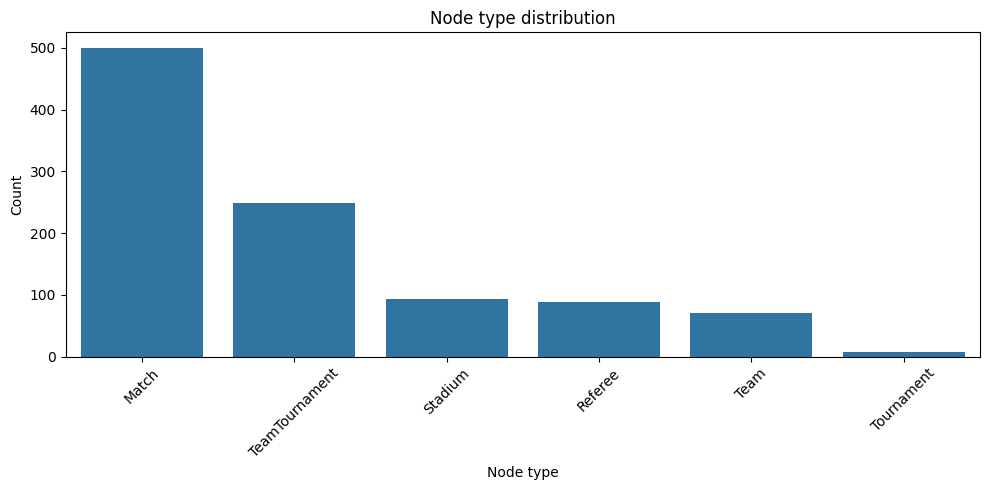

In [8]:
node_type_counts = graph_nodes["node_type"].value_counts()

display(node_type_counts)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=node_type_counts.index,
    y=node_type_counts.values,
)
plt.title("Node type distribution")
plt.xlabel("Node type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


edge_type
team_played_match                  1000
team_played_against_team           1000
team_tournament_played_match       1000
match_belongs_to_tournament         500
match_played_at_stadium             500
team_participated_in_tournament     248
team_has_tournament_instance        248
referee_officiated_match            245
Name: count, dtype: int64

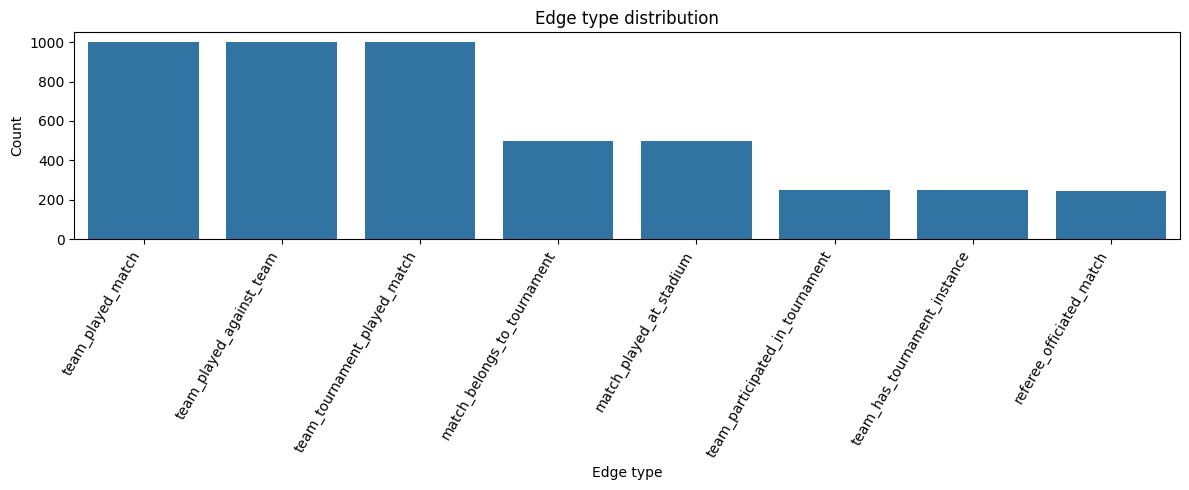

In [9]:
edge_type_counts = graph_edges["edge_type"].value_counts()

display(edge_type_counts)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=edge_type_counts.index,
    y=edge_type_counts.values,
)
plt.title("Edge type distribution")
plt.xlabel("Edge type")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


# Проверка связности графа

In [10]:
def build_networkx_graph(nodes_df, edges_df, directed=True):
    """
    Строит NetworkX graph из таблиц nodes/edges.
    """
    if directed:
        G = nx.DiGraph()
    else:
        G = nx.Graph()

    for _, r in nodes_df.iterrows():
        G.add_node(
            r["node_id"],
            node_type=r.get("node_type"),
            name=r.get("name"),
            canonical_name=r.get("canonical_name"),
            tournament_year=r.get("tournament_year"),
            metadata_json=r.get("metadata_json"),
        )

    for _, r in edges_df.iterrows():
        source = r["source_node_id"]
        target = r["target_node_id"]

        if pd.isna(source) or pd.isna(target):
            continue

        G.add_edge(
            source,
            target,
            edge_id=r.get("edge_id"),
            edge_type=r.get("edge_type"),
            match_id=r.get("match_id"),
            tournament_id=r.get("tournament_id"),
            tournament_year=r.get("tournament_year"),
            weight=r.get("weight", 1.0),
            metadata_json=r.get("metadata_json"),
        )

    return G


G_directed = build_networkx_graph(graph_nodes, graph_edges, directed=True)
G_undirected = build_networkx_graph(graph_nodes, graph_edges, directed=False)

print("Directed graph:")
print("Nodes:", G_directed.number_of_nodes())
print("Edges:", G_directed.number_of_edges())

print("\nUndirected graph:")
print("Nodes:", G_undirected.number_of_nodes())
print("Edges:", G_undirected.number_of_edges())

components = list(nx.connected_components(G_undirected))
components_sizes = sorted([len(c) for c in components], reverse=True)

print("\nConnected components:", len(components))
print("Largest components:", components_sizes[:10])


Directed graph:
Nodes: 1007
Edges: 4539

Undirected graph:
Nodes: 1007
Edges: 4140

Connected components: 1
Largest components: [1007]


# Static visualization через NetworkX

In [11]:
NODE_COLOR_MAP = {
    "Team": "#1f77b4",
    "Match": "#ff7f0e",
    "Tournament": "#2ca02c",
    "Stadium": "#9467bd",
    "Referee": "#8c564b",
    "Manager": "#e377c2",
    "Player": "#7f7f7f",
    "TeamTournament": "#17becf",
}

NODE_SIZE_MAP = {
    "Team": 500,
    "Match": 120,
    "Tournament": 800,
    "Stadium": 250,
    "Referee": 180,
    "Manager": 180,
    "Player": 80,
    "TeamTournament": 250,
}


In [12]:
def draw_networkx_subgraph(
    G,
    title="Graph",
    max_nodes=120,
    figsize=(14, 10),
    seed=42,
    show_labels=True,
):
    """
    Рисует небольшой подграф через NetworkX.
    """
    if G.number_of_nodes() > max_nodes:
        print(f"[WARN] Graph has {G.number_of_nodes()} nodes. Sampling top-degree {max_nodes} nodes.")
        degrees = dict(G.degree())
        top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:max_nodes]
        H = G.subgraph(top_nodes).copy()
    else:
        H = G.copy()

    node_colors = []
    node_sizes = []

    for n, data in H.nodes(data=True):
        node_type = data.get("node_type", "Unknown")
        node_colors.append(NODE_COLOR_MAP.get(node_type, "#cccccc"))
        node_sizes.append(NODE_SIZE_MAP.get(node_type, 150))

    plt.figure(figsize=figsize)

    pos = nx.spring_layout(H, seed=seed, k=0.6)

    nx.draw_networkx_edges(
        H,
        pos,
        alpha=0.25,
        arrows=False,
        width=0.8,
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9,
    )

    if show_labels:
        labels = {
            n: data.get("name", str(n))[:25]
            for n, data in H.nodes(data=True)
            if data.get("node_type") in ["Team", "Tournament"]
        }

        nx.draw_networkx_labels(
            H,
            pos,
            labels=labels,
            font_size=8,
        )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return H


[WARN] Graph has 1007 nodes. Sampling top-degree 120 nodes.


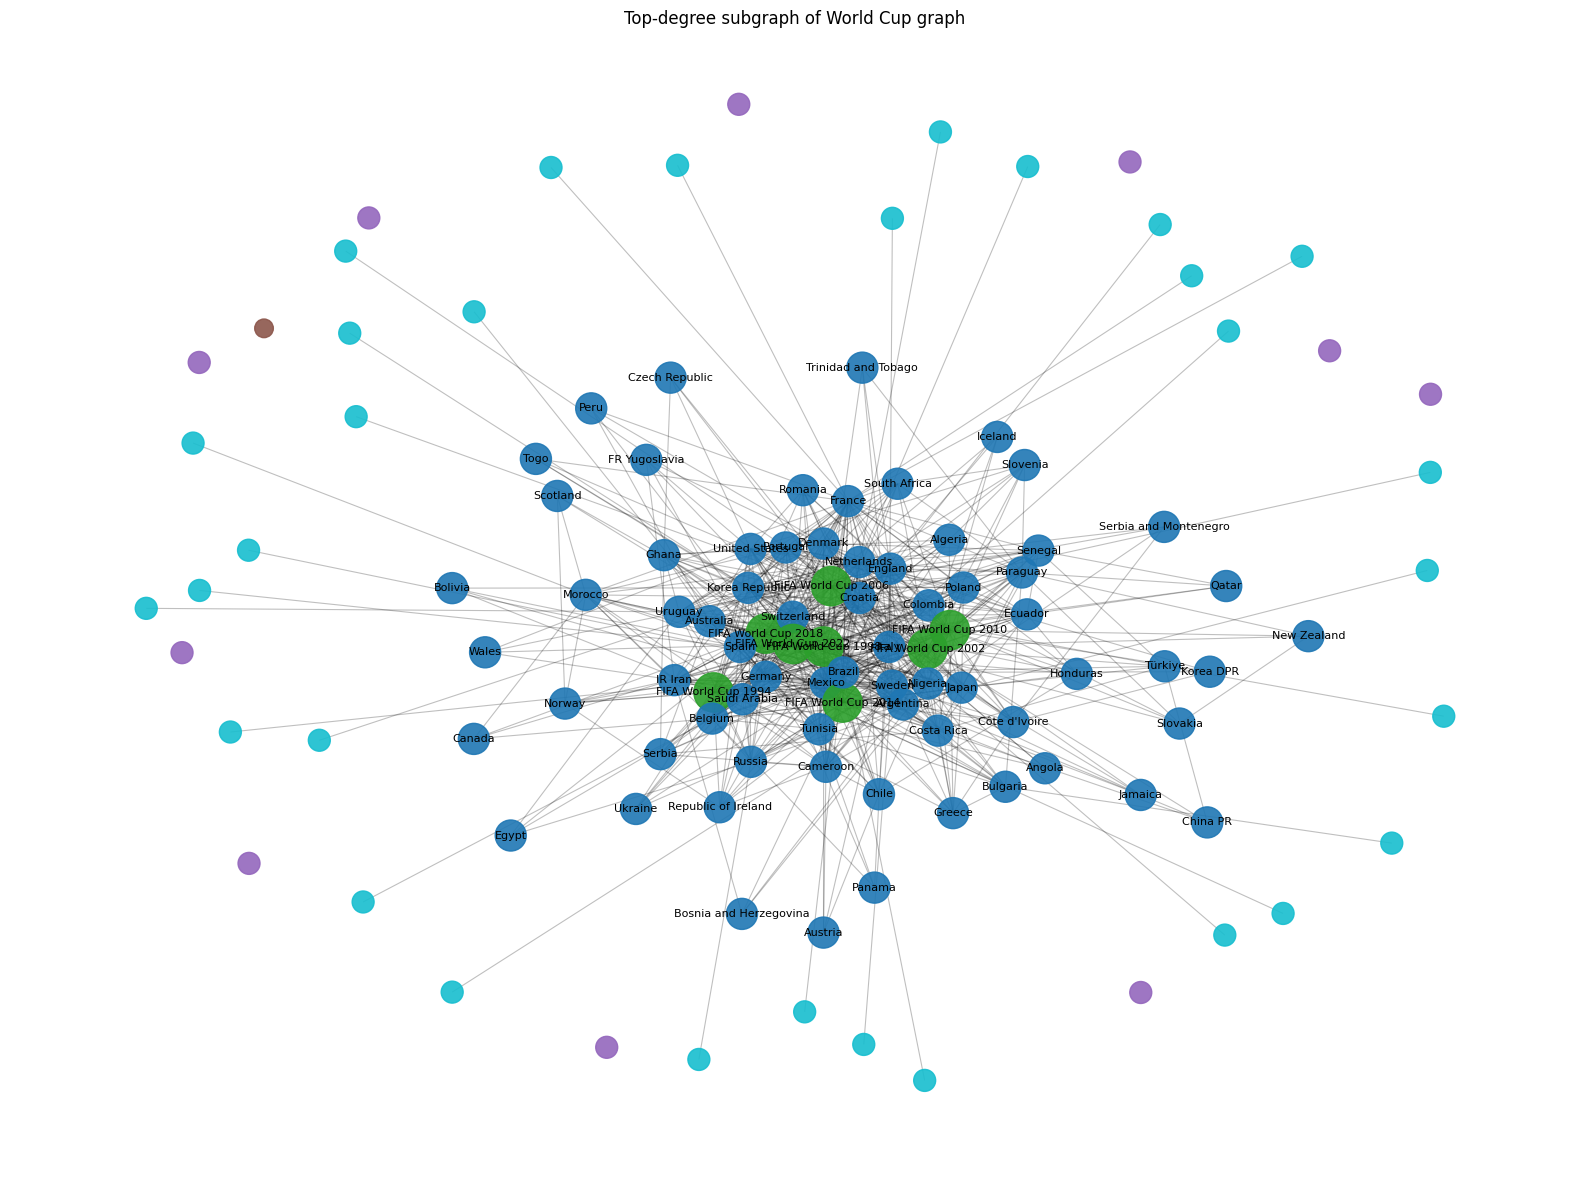

In [13]:
H_top = draw_networkx_subgraph(
    G_undirected,
    title="Top-degree subgraph of World Cup graph",
    max_nodes=120,
    figsize=(16, 12),
    show_labels=True,
)


# Интерактивная визуализация через PyVis

In [14]:
def visualize_pyvis_graph(
    G,
    output_html,
    height="750px",
    width="100%",
    notebook=True,
    max_nodes=300,
    title="World Cup Graph",
):
    """
    Создает интерактивный HTML-граф через PyVis.
    """
    if G.number_of_nodes() > max_nodes:
        print(f"[WARN] Graph has {G.number_of_nodes()} nodes. Sampling top-degree {max_nodes} nodes.")
        degrees = dict(G.degree())
        top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:max_nodes]
        H = G.subgraph(top_nodes).copy()
    else:
        H = G.copy()

    net = Network(
        height=height,
        width=width,
        notebook=notebook,
        directed=False,
        bgcolor="#ffffff",
        font_color="#222222",
    )

    net.barnes_hut(
        gravity=-35000,
        central_gravity=0.25,
        spring_length=140,
        spring_strength=0.02,
        damping=0.09,
    )

    for n, data in H.nodes(data=True):
        node_type = data.get("node_type", "Unknown")
        name = data.get("name", str(n))

        color = NODE_COLOR_MAP.get(node_type, "#cccccc")
        size = NODE_SIZE_MAP.get(node_type, 150) / 20

        title_text = (
            f"<b>{name}</b><br>"
            f"Type: {node_type}<br>"
            f"ID: {n}<br>"
            f"Tournament year: {data.get('tournament_year')}"
        )

        net.add_node(
            n,
            label=str(name)[:35],
            title=title_text,
            color=color,
            size=size,
            group=node_type,
        )

    for u, v, data in H.edges(data=True):
        edge_type = data.get("edge_type", "edge")
        weight = data.get("weight", 1.0)

        title_text = (
            f"Type: {edge_type}<br>"
            f"Match: {data.get('match_id')}<br>"
            f"Tournament: {data.get('tournament_id')}"
        )

        net.add_edge(
            u,
            v,
            title=title_text,
            value=float(weight) if weight is not None else 1.0,
        )

    output_html = Path(output_html)
    output_html.parent.mkdir(parents=True, exist_ok=True)

    net.show(str(output_html))

    return output_html


# Интерактивный top-degree graph

In [15]:
top_graph_html = VIS_DIR / "top_degree_worldcup_graph.html"

visualize_pyvis_graph(
    G_undirected,
    output_html=top_graph_html,
    max_nodes=250,
    title="Top-degree World Cup Graph",
)

display(IFrame(str(top_graph_html), width="100%", height="800px"))


[WARN] Graph has 1007 nodes. Sampling top-degree 250 nodes.
/Users/gaperov/Documents/University/SNA/data/processed/graph_visualizations/top_degree_worldcup_graph.html


# Визуализация ego-графа команды

In [16]:
def find_team_nodes(nodes_df, query):
    """
    Ищет команды по строке query.
    """
    q = query.lower()

    teams = nodes_df[nodes_df["node_type"] == "Team"].copy()

    mask = (
        teams["name"].astype(str).str.lower().str.contains(q, na=False)
        | teams["canonical_name"].astype(str).str.lower().str.contains(q, na=False)
    )

    return teams[mask].copy()


display(find_team_nodes(graph_nodes, "brazil"))
display(find_team_nodes(graph_nodes, "argentina"))
display(find_team_nodes(graph_nodes, "france"))


,node_id,node_type,name,canonical_name,source_id,tournament_year,metadata_json
9,team_6e5fa4d9c48c,Team,Brazil,brazil,NaN,NaN,"{""team_norm"": ""brazil""}"


,node_id,node_type,name,canonical_name,source_id,tournament_year,metadata_json
10,team_2a52adc7b1da,Team,Argentina,argentina,NaN,NaN,"{""team_norm"": ""argentina""}"


,node_id,node_type,name,canonical_name,source_id,tournament_year,metadata_json
25,team_e165d4f2174b,Team,France,france,NaN,NaN,"{""team_norm"": ""france""}"


# Создание ego-графа команды

```
Brazil -> matches -> opponents/tournaments
```

In [17]:
def get_team_ego_graph(G, nodes_df, team_query, radius=2):
    """
    Возвращает ego graph команды.
    """
    candidates = find_team_nodes(nodes_df, team_query)

    if candidates.empty:
        raise ValueError(f"No team found for query: {team_query}")

    team_id = candidates.iloc[0]["node_id"]

    H = nx.ego_graph(
        G,
        team_id,
        radius=radius,
        undirected=True,
    )

    print("Team:", candidates.iloc[0]["name"])
    print("Team ID:", team_id)
    print("Ego graph nodes:", H.number_of_nodes())
    print("Ego graph edges:", H.number_of_edges())

    return H, team_id


### Static ego-граф Brazil

Team: Brazil
Team ID: team_6e5fa4d9c48c
Ego graph nodes: 787
Ego graph edges: 3235
[WARN] Graph has 787 nodes. Sampling top-degree 150 nodes.


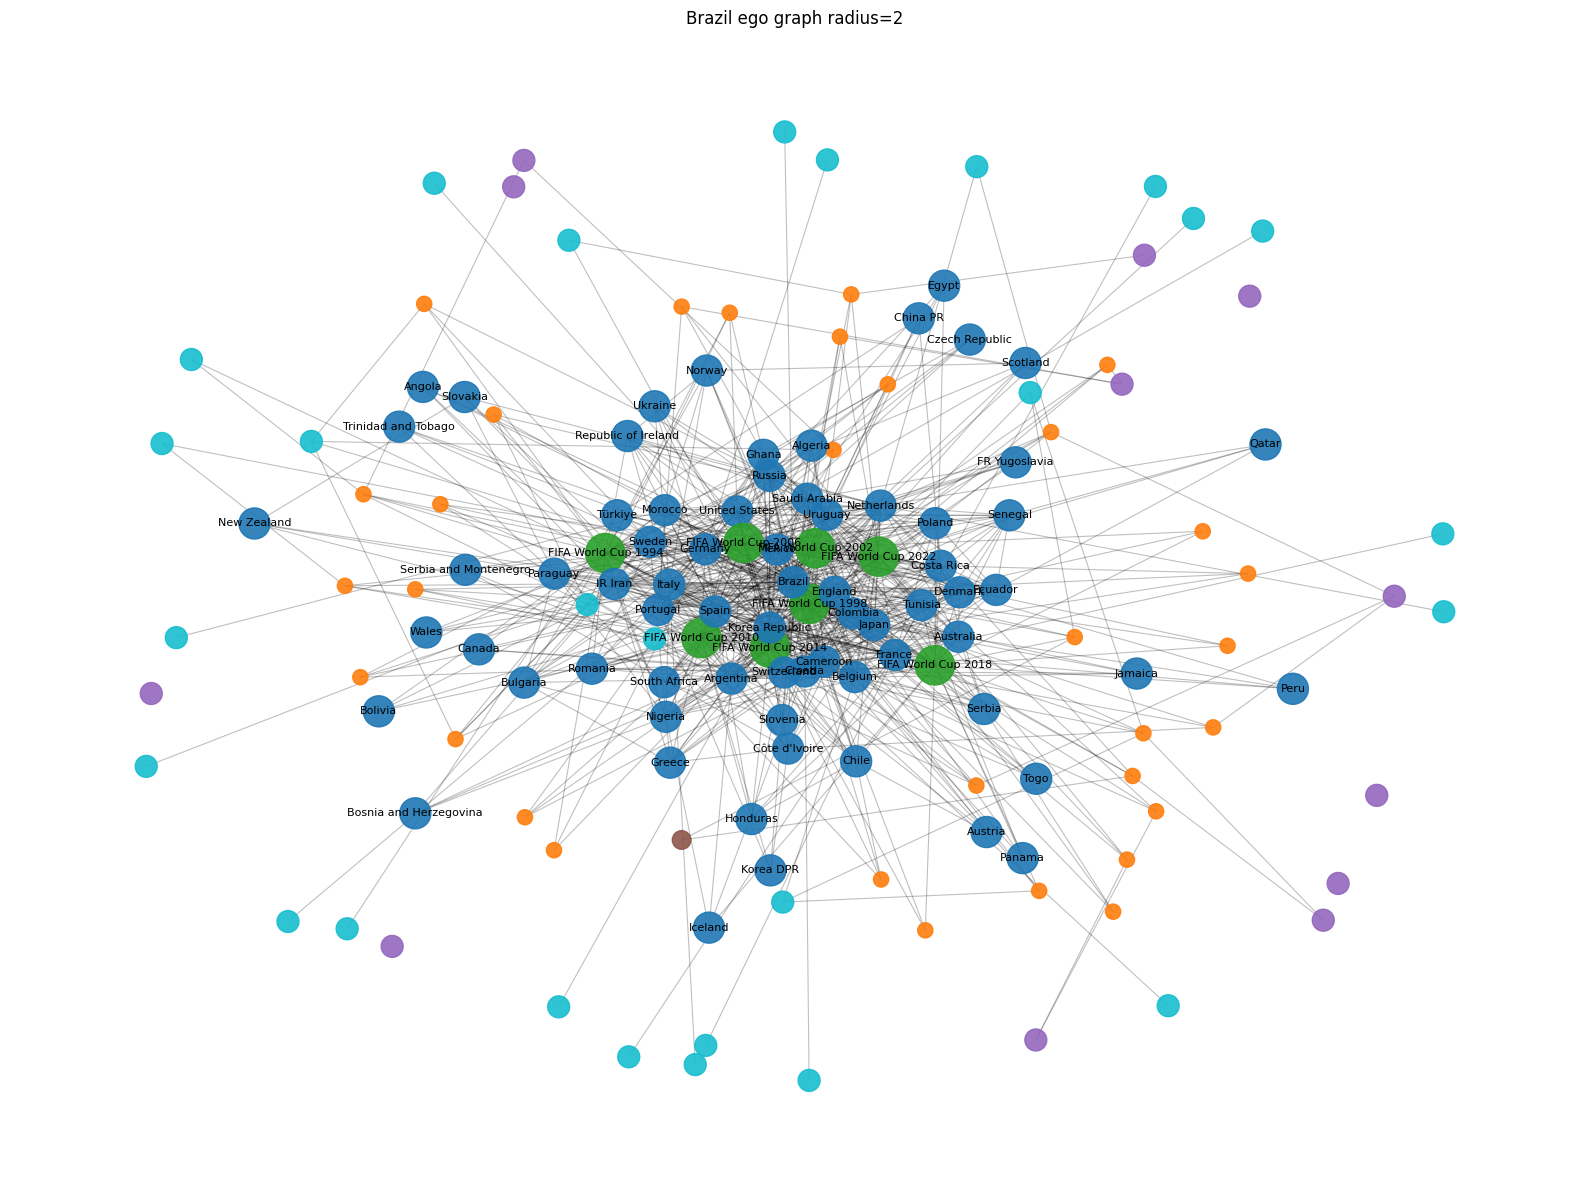

In [18]:
brazil_ego, brazil_id = get_team_ego_graph(
    G_undirected,
    graph_nodes,
    team_query="brazil",
    radius=2,
)

draw_networkx_subgraph(
    brazil_ego,
    title="Brazil ego graph radius=2",
    max_nodes=150,
    figsize=(16, 12),
    show_labels=True,
)


# Interactive ego-граф Brazil

In [19]:
brazil_html = VIS_DIR / "brazil_ego_graph.html"

visualize_pyvis_graph(
    brazil_ego,
    output_html=brazil_html,
    max_nodes=300,
    title="Brazil ego graph",
)

display(IFrame(str(brazil_html), width="100%", height="800px"))


[WARN] Graph has 787 nodes. Sampling top-degree 300 nodes.
/Users/gaperov/Documents/University/SNA/data/processed/graph_visualizations/brazil_ego_graph.html


# Визуализация одного турнира

In [21]:
def get_tournament_subgraph(G, nodes_df, edges_df, tournament_year):
    """
    Возвращает подграф одного турнира по tournament_year.
    """
    tournament_id = f"wc_{int(tournament_year)}"

    edge_subset = edges_df[
        edges_df["tournament_id"].astype(str).eq(tournament_id)
        | edges_df["tournament_year"].astype(str).eq(str(int(tournament_year)))
    ].copy()

    node_ids = set(edge_subset["source_node_id"].dropna()).union(
        set(edge_subset["target_node_id"].dropna())
    )

    if tournament_id in G.nodes:
        node_ids.add(tournament_id)

    H = G.subgraph(node_ids).copy()

    print(f"Tournament {tournament_year}")
    print("Nodes:", H.number_of_nodes())
    print("Edges:", H.number_of_edges())

    node_types = pd.Series(
        [data.get("node_type") for _, data in H.nodes(data=True)]
    ).value_counts()

    display(node_types)

    return H


### Static graph турнира 2022

Tournament 2022
Nodes: 166
Edges: 707


Match             64
TeamTournament    32
Team              32
Referee           29
Stadium            8
Tournament         1
Name: count, dtype: int64

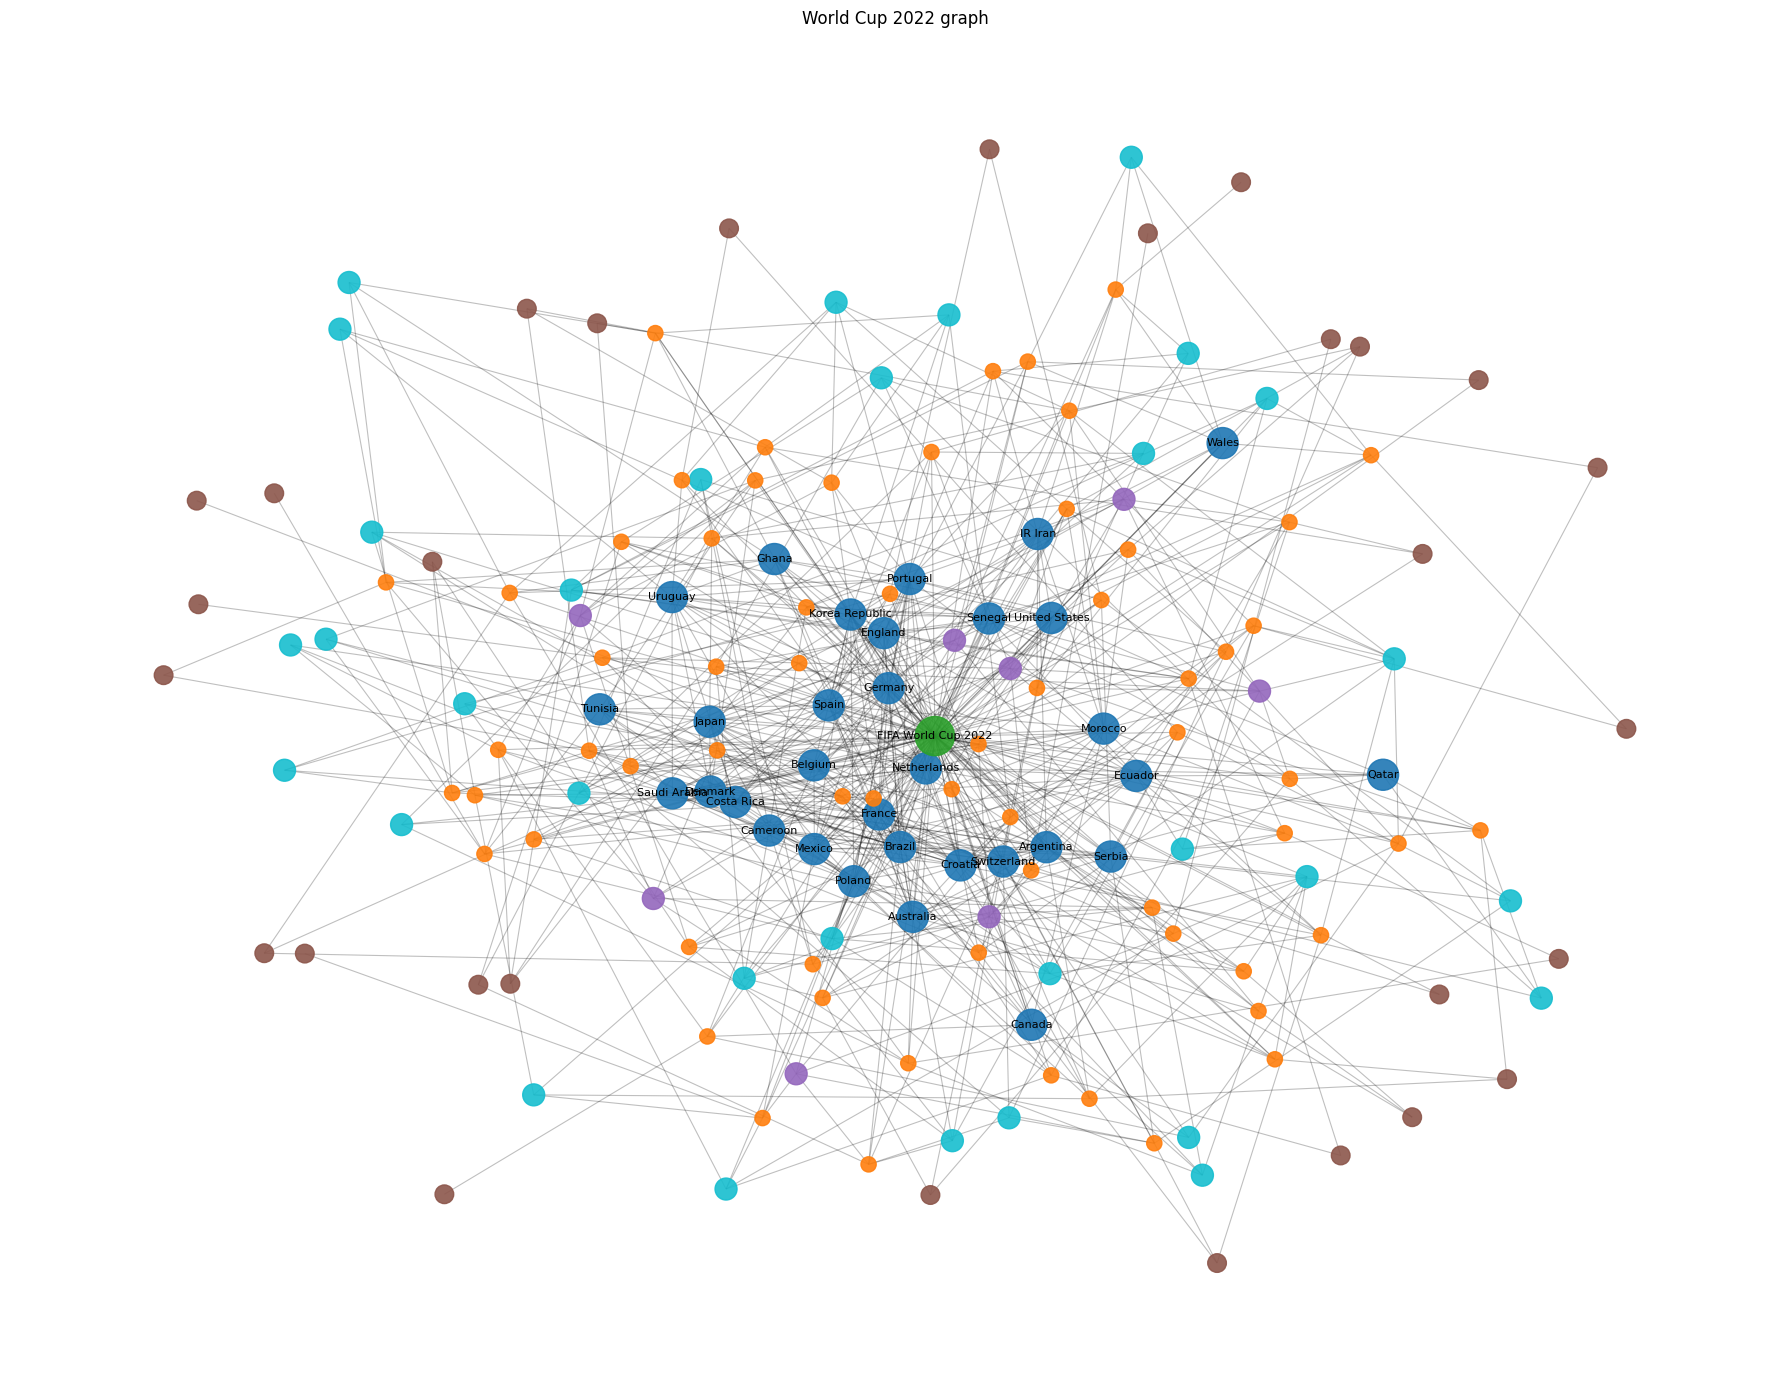

In [22]:
wc2022_graph = get_tournament_subgraph(
    G_undirected,
    graph_nodes,
    graph_edges,
    tournament_year=2022,
)

draw_networkx_subgraph(
    wc2022_graph,
    title="World Cup 2022 graph",
    max_nodes=200,
    figsize=(18, 14),
    show_labels=True,
)


### Interactive graph турнира 2022

In [23]:
wc2022_html = VIS_DIR / "worldcup_2022_graph.html"

visualize_pyvis_graph(
    wc2022_graph,
    output_html=wc2022_html,
    max_nodes=500,
    title="World Cup 2022 Graph",
)

display(IFrame(str(wc2022_html), width="100%", height="800px"))


/Users/gaperov/Documents/University/SNA/data/processed/graph_visualizations/worldcup_2022_graph.html


# Визуализация одного матча

In [24]:
def find_matches_in_nodes(nodes_df, query):
    """
    Ищет match nodes по строке.
    """
    q = query.lower()

    matches = nodes_df[nodes_df["node_type"] == "Match"].copy()

    mask = (
        matches["name"].astype(str).str.lower().str.contains(q, na=False)
        | matches["canonical_name"].astype(str).str.lower().str.contains(q, na=False)
    )

    return matches[mask].copy()


display(find_matches_in_nodes(graph_nodes, "argentina vs france"))
display(find_matches_in_nodes(graph_nodes, "brazil"))


,node_id,node_type,name,canonical_name,source_id,tournament_year,metadata_json
569,match_438f9a929e58,Match,Argentina vs France 2022,match_438f9a929e58,match_438f9a929e58,2022.0,"{""match_date"": ""2022-12-18 00:00:00"", ""stage"":..."


,node_id,node_type,name,canonical_name,source_id,tournament_year,metadata_json
79,match_d05bcda4412b,Match,Brazil vs Russia 1994,match_d05bcda4412b,match_d05bcda4412b,1994.0,"{""match_date"": ""1994-06-20 00:00:00"", ""stage"":..."
88,match_ad316d029fe3,Match,Brazil vs Cameroon 1994,match_ad316d029fe3,match_ad316d029fe3,1994.0,"{""match_date"": ""1994-06-24 00:00:00"", ""stage"":..."
98,match_4e49076d1d4e,Match,Brazil vs Sweden 1994,match_4e49076d1d4e,match_4e49076d1d4e,1994.0,"{""match_date"": ""1994-06-28 00:00:00"", ""stage"":..."
111,match_eb01019f7320,Match,Brazil vs United States 1994,match_eb01019f7320,match_eb01019f7320,1994.0,"{""match_date"": ""1994-07-04 00:00:00"", ""stage"":..."
114,match_3b0d4347abde,Match,Netherlands vs Brazil 1994,match_3b0d4347abde,match_3b0d4347abde,1994.0,"{""match_date"": ""1994-07-09 00:00:00"", ""stage"":..."
118,match_4890e4e757d6,Match,Sweden vs Brazil 1994,match_4890e4e757d6,match_4890e4e757d6,1994.0,"{""match_date"": ""1994-07-13 00:00:00"", ""stage"":..."
121,match_01a014e4b89e,Match,Brazil vs Italy 1994,match_01a014e4b89e,match_01a014e4b89e,1994.0,"{""match_date"": ""1994-07-17 00:00:00"", ""stage"":..."
122,match_2cdd72b027ee,Match,Brazil vs Scotland 1998,match_2cdd72b027ee,match_2cdd72b027ee,1998.0,"{""match_date"": ""1998-06-10 00:00:00"", ""stage"":..."
138,match_0d0c1a1e0015,Match,Brazil vs Morocco 1998,match_0d0c1a1e0015,match_0d0c1a1e0015,1998.0,"{""match_date"": ""1998-06-16 00:00:00"", ""stage"":..."
154,match_152435c399ba,Match,Brazil vs Norway 1998,match_152435c399ba,match_152435c399ba,1998.0,"{""match_date"": ""1998-06-23 00:00:00"", ""stage"":..."


### Ego-граф одного матча

In [26]:
def get_match_ego_graph(G, nodes_df, match_query, radius=2):
    """
    Возвращает ego graph матча.
    """
    candidates = find_matches_in_nodes(nodes_df, match_query)

    if candidates.empty:
        raise ValueError(f"No match found for query: {match_query}")

    display(candidates[["node_id", "name", "tournament_year"]].head(20))

    match_id = candidates.iloc[0]["node_id"]

    H = nx.ego_graph(
        G,
        match_id,
        radius=radius,
        undirected=True,
    )

    print("Match:", candidates.iloc[0]["name"])
    print("Match ID:", match_id)
    print("Ego graph nodes:", H.number_of_nodes())
    print("Ego graph edges:", H.number_of_edges())

    return H, match_id


### Визуализация матча Argentina vs France

,node_id,name,tournament_year
569,match_438f9a929e58,Argentina vs France 2022,2022.0


Match: Argentina vs France 2022
Match ID: match_438f9a929e58
Ego graph nodes: 202
Ego graph edges: 1004
[WARN] Graph has 202 nodes. Sampling top-degree 80 nodes.


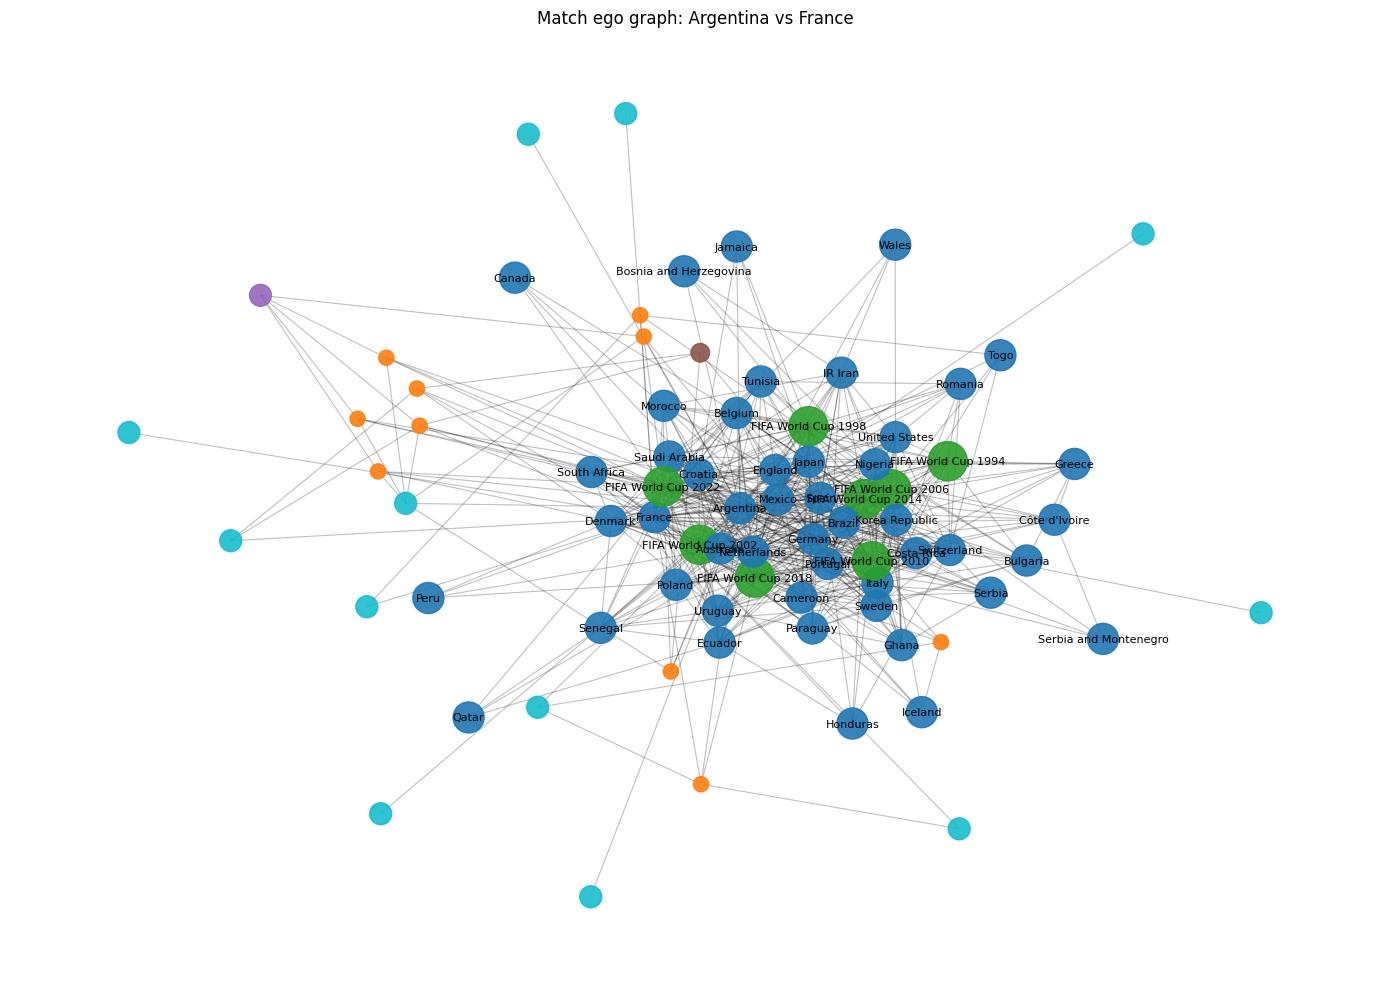

In [27]:
match_ego, match_id = get_match_ego_graph(
    G_undirected,
    graph_nodes,
    match_query="Argentina vs France",
    radius=2,
)

draw_networkx_subgraph(
    match_ego,
    title="Match ego graph: Argentina vs France",
    max_nodes=80,
    figsize=(14, 10),
    show_labels=True,
)


### Interactive match ego graph

In [28]:
match_html = VIS_DIR / "match_ego_argentina_france.html"

visualize_pyvis_graph(
    match_ego,
    output_html=match_html,
    max_nodes=150,
    title="Match Ego Graph",
)

display(IFrame(str(match_html), width="100%", height="750px"))


[WARN] Graph has 202 nodes. Sampling top-degree 150 nodes.
/Users/gaperov/Documents/University/SNA/data/processed/graph_visualizations/match_ego_argentina_france.html


# Team-vs-Team rivalry graph

```
Team -> Team
```
по матчам между командами.

### Создание rivalry graph

In [29]:
def build_team_rivalry_graph(nodes_df, edges_df, min_matches=1):
    """
    Создает Team-vs-Team graph из edge_type team_played_against_team.
    Вес ребра = количество встреч.
    """
    team_edges = edges_df[
        edges_df["edge_type"] == "team_played_against_team"
    ].copy()

    # Для undirected rivalry нужно нормализовать пару команд
    team_edges["team_a"] = team_edges[["source_node_id", "target_node_id"]].min(axis=1)
    team_edges["team_b"] = team_edges[["source_node_id", "target_node_id"]].max(axis=1)

    grouped = (
        team_edges.groupby(["team_a", "team_b"])
        .agg(
            matches=("match_id", "nunique"),
            years=("tournament_year", lambda x: ",".join(map(str, sorted(set(x.dropna().astype(int)))))),
        )
        .reset_index()
    )

    grouped = grouped[grouped["matches"] >= min_matches].copy()

    team_lookup = (
        nodes_df[nodes_df["node_type"] == "Team"]
        .set_index("node_id")["name"]
        .to_dict()
    )

    R = nx.Graph()

    for team_id, name in team_lookup.items():
        R.add_node(
            team_id,
            node_type="Team",
            name=name,
        )

    for _, r in grouped.iterrows():
        R.add_edge(
            r["team_a"],
            r["team_b"],
            weight=float(r["matches"]),
            matches=int(r["matches"]),
            years=r["years"],
            edge_type="rivalry",
        )

    # Удаляем изолированные команды
    isolated = list(nx.isolates(R))
    R.remove_nodes_from(isolated)

    print("Rivalry graph nodes:", R.number_of_nodes())
    print("Rivalry graph edges:", R.number_of_edges())

    return R, grouped


rivalry_graph, rivalry_edges = build_team_rivalry_graph(
    graph_nodes,
    graph_edges,
    min_matches=2,
)

display(rivalry_edges.sort_values("matches", ascending=False).head(20))


Rivalry graph nodes: 39
Rivalry graph edges: 78


,team_a,team_b,matches,years
171,team_2a52adc7b1da,team_f174114ad69e,5,"1994,2002,2010,2014,2018"
291,team_6123486432d2,team_6e5fa4d9c48c,4,"1994,1998,2010,2014"
388,team_e165d4f2174b,team_e9375700acbb,4,"1998,2002,2018,2022"
160,team_2a52adc7b1da,team_6123486432d2,4,"1998,2006,2014,2022"
351,team_88e52ee42fd0,team_f48861ca24e2,3,"2002,2006,2018"
329,team_6e5fa4d9c48c,team_fd317045cbdc,3,"1998,2010,2014"
128,team_28ef36b35ae8,team_2a52adc7b1da,3,"2006,2010,2014"
50,team_1747d4b2dd4b,team_3bafbfd8bf5e,3,"1998,2002,2010"
49,team_1747d4b2dd4b,team_28ef36b35ae8,3,"1994,2010,2022"
110,team_267640588a39,team_2a52adc7b1da,3,"1998,2018,2022"


### Static rivalry graph

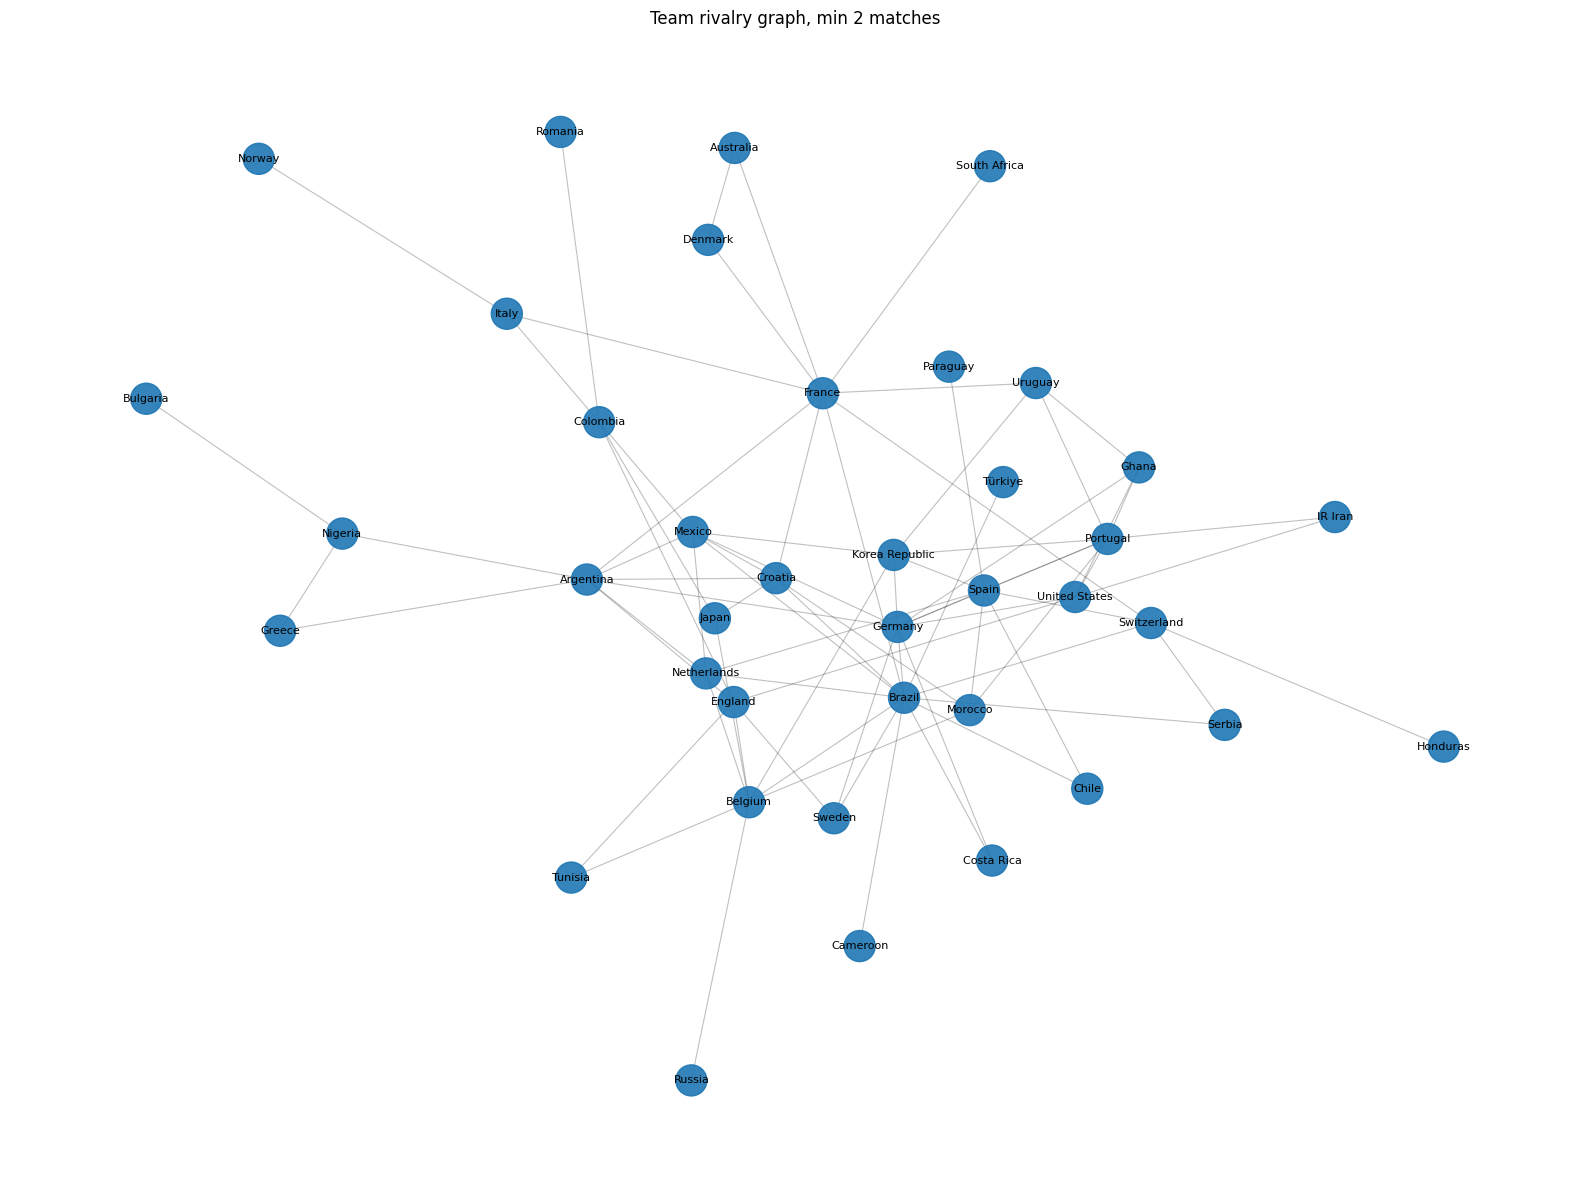

In [30]:
draw_networkx_subgraph(
    rivalry_graph,
    title="Team rivalry graph, min 2 matches",
    max_nodes=100,
    figsize=(16, 12),
    show_labels=True,
)


### Interactive rivalry graph

In [31]:
rivalry_html = VIS_DIR / "team_rivalry_graph.html"

visualize_pyvis_graph(
    rivalry_graph,
    output_html=rivalry_html,
    max_nodes=150,
    title="Team Rivalry Graph",
)

display(IFrame(str(rivalry_html), width="100%", height="800px"))


/Users/gaperov/Documents/University/SNA/data/processed/graph_visualizations/team_rivalry_graph.html


# Bipartite Team-Match graph

Создание Team-Match подграфа

Что делает: Создает двудольный граф:
```
Team -- Match
```
Для выбранного турнира.

In [32]:
def get_team_match_bipartite_graph(G, nodes_df, edges_df, tournament_year=None):
    """
    Создает Team-Match bipartite graph.
    """
    e = edges_df[edges_df["edge_type"] == "team_played_match"].copy()

    if tournament_year is not None:
        e = e[e["tournament_year"].astype(str).eq(str(int(tournament_year)))].copy()

    node_ids = set(e["source_node_id"]).union(set(e["target_node_id"]))

    H = G.subgraph(node_ids).copy()

    print("Team-Match bipartite graph")
    print("Tournament:", tournament_year)
    print("Nodes:", H.number_of_nodes())
    print("Edges:", H.number_of_edges())

    return H


team_match_2022 = get_team_match_bipartite_graph(
    G_undirected,
    graph_nodes,
    graph_edges,
    tournament_year=2022,
)


Team-Match bipartite graph
Tournament: 2022
Nodes: 96
Edges: 323


### Static bipartite graph

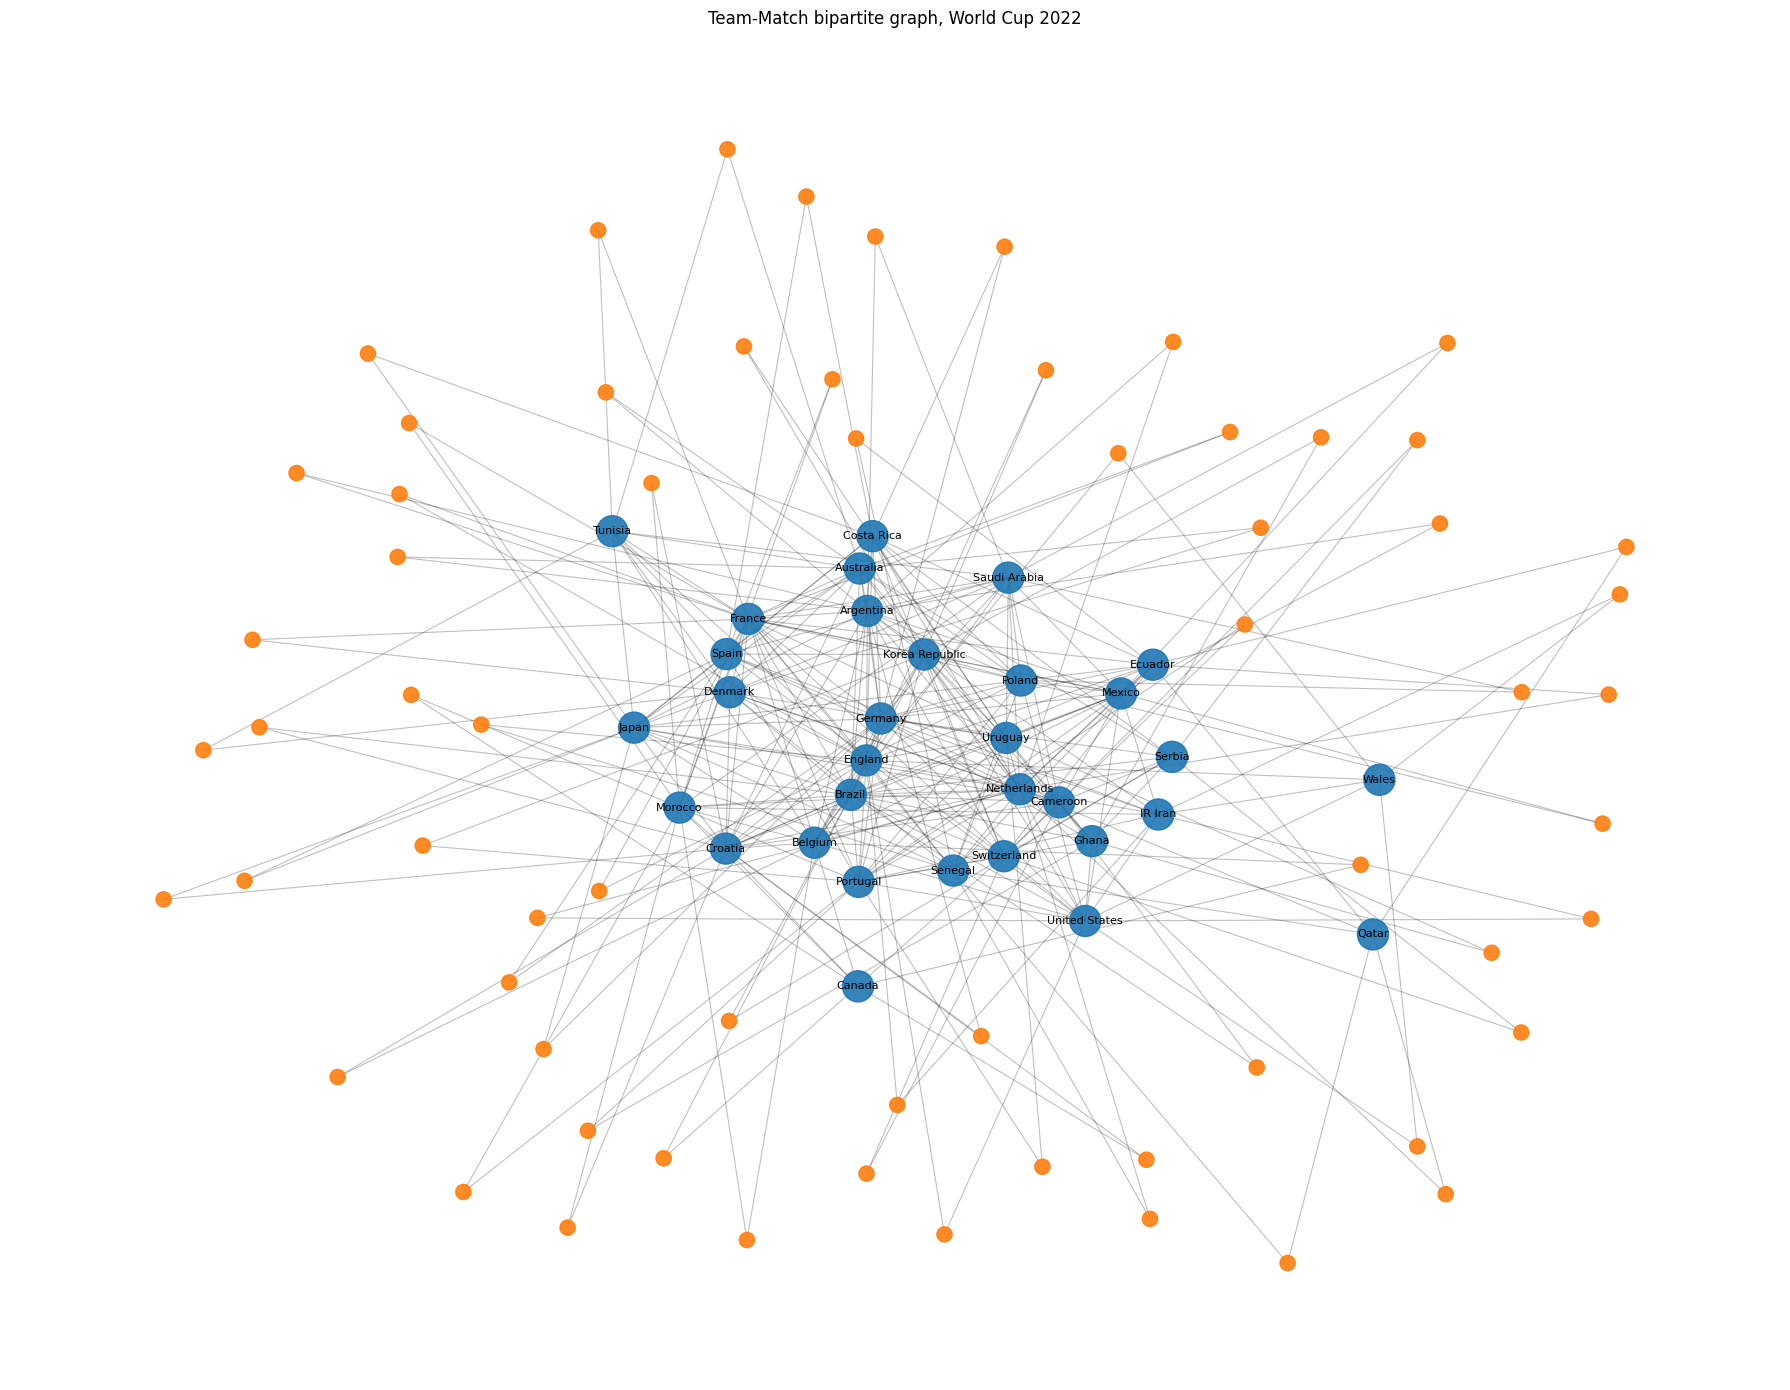

In [33]:
draw_networkx_subgraph(
    team_match_2022,
    title="Team-Match bipartite graph, World Cup 2022",
    max_nodes=160,
    figsize=(18, 14),
    show_labels=True,
)


### Interactive bipartite graph

In [34]:
team_match_2022_html = VIS_DIR / "team_match_bipartite_2022.html"

visualize_pyvis_graph(
    team_match_2022,
    output_html=team_match_2022_html,
    max_nodes=250,
    title="Team-Match Bipartite Graph 2022",
)

display(IFrame(str(team_match_2022_html), width="100%", height="800px"))


/Users/gaperov/Documents/University/SNA/data/processed/graph_visualizations/team_match_bipartite_2022.html


# Центральности графа

### Degree centrality по командам

In [35]:
degree_centrality = nx.degree_centrality(G_undirected)

team_nodes = graph_nodes[graph_nodes["node_type"] == "Team"].copy()

team_nodes["degree_centrality"] = team_nodes["node_id"].map(degree_centrality)
team_nodes["degree"] = team_nodes["node_id"].map(dict(G_undirected.degree()))

top_teams_degree = team_nodes.sort_values("degree", ascending=False)

display(top_teams_degree[["name", "degree", "degree_centrality"]].head(20))


,name,degree,degree_centrality
9,Brazil,94,0.093439
0,Germany,90,0.089463
25,France,80,0.079523
10,Argentina,80,0.079523
1,Spain,76,0.075547
8,Netherlands,73,0.072565
28,England,73,0.072565
14,Mexico,70,0.069583
13,Korea Republic,69,0.068588
3,Italy,67,0.066600


### Barplot top teams by degree

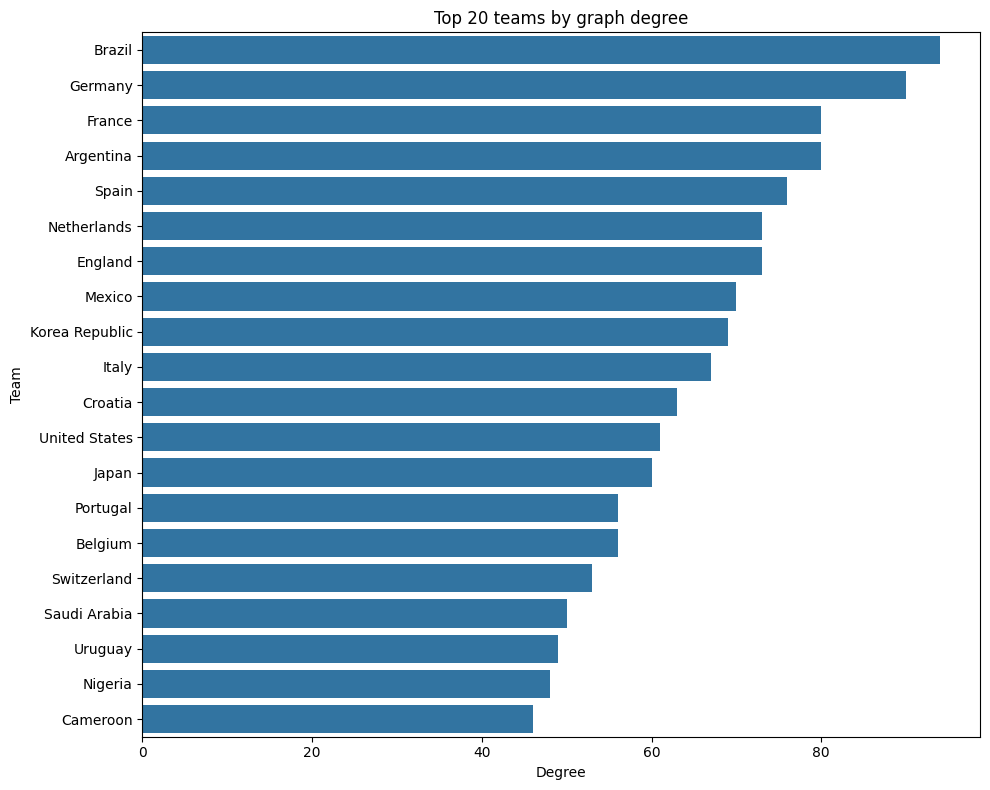

In [36]:
top_n = 20

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_teams_degree.head(top_n),
    y="name",
    x="degree",
)
plt.title(f"Top {top_n} teams by graph degree")
plt.xlabel("Degree")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


# Визуализация text coverage в графе

### Извлечение text_available из Match nodes

In [37]:
def parse_metadata_json_safe(x):
    if pd.isna(x):
        return {}

    if isinstance(x, dict):
        return x

    try:
        return json.loads(x)
    except Exception:
        return {}


match_nodes = graph_nodes[graph_nodes["node_type"] == "Match"].copy()
match_nodes["metadata"] = match_nodes["metadata_json"].apply(parse_metadata_json_safe)

match_nodes["text_available"] = match_nodes["metadata"].apply(
    lambda d: d.get("text_available", np.nan)
)

match_nodes["text_count"] = match_nodes["metadata"].apply(
    lambda d: d.get("text_count", np.nan)
)

match_nodes["stage_norm"] = match_nodes["metadata"].apply(
    lambda d: d.get("stage_norm", None)
)

display(match_nodes.head())


,node_id,node_type,name,canonical_name,source_id,tournament_year,metadata_json,metadata,text_available,text_count,stage_norm
70,match_24ab401684d2,Match,Germany vs Bolivia 1994,match_24ab401684d2,match_24ab401684d2,1994.0,"{""match_date"": ""1994-06-17 00:00:00"", ""stage"":...","{'match_date': '1994-06-17 00:00:00', 'stage':...",0,0,group
71,match_38ef6f79f047,Match,Spain vs Korea Republic 1994,match_38ef6f79f047,match_38ef6f79f047,1994.0,"{""match_date"": ""1994-06-17 00:00:00"", ""stage"":...","{'match_date': '1994-06-17 00:00:00', 'stage':...",0,0,group
72,match_ebe85d2cc918,Match,Colombia vs Romania 1994,match_ebe85d2cc918,match_ebe85d2cc918,1994.0,"{""match_date"": ""1994-06-18 00:00:00"", ""stage"":...","{'match_date': '1994-06-18 00:00:00', 'stage':...",0,0,group
73,match_f0b250615ce7,Match,Italy vs Republic of Ireland 1994,match_f0b250615ce7,match_f0b250615ce7,1994.0,"{""match_date"": ""1994-06-18 00:00:00"", ""stage"":...","{'match_date': '1994-06-18 00:00:00', 'stage':...",0,0,group
74,match_fd7cb15508dc,Match,United States vs Switzerland 1994,match_fd7cb15508dc,match_fd7cb15508dc,1994.0,"{""match_date"": ""1994-06-18 00:00:00"", ""stage"":...","{'match_date': '1994-06-18 00:00:00', 'stage':...",0,0,group


### Text coverage by tournament year

,tournament_year,matches,matches_with_text,avg_text_count,coverage_rate
0,1994.0,52,1,0.019231,0.019231
1,1998.0,64,1,0.015625,0.015625
2,2002.0,64,57,1.843750,0.890625
3,2006.0,64,39,1.703125,0.609375
4,2010.0,64,61,2.343750,0.953125
5,2014.0,64,62,3.328125,0.968750
6,2018.0,64,51,1.812500,0.796875
7,2022.0,64,49,2.109375,0.765625


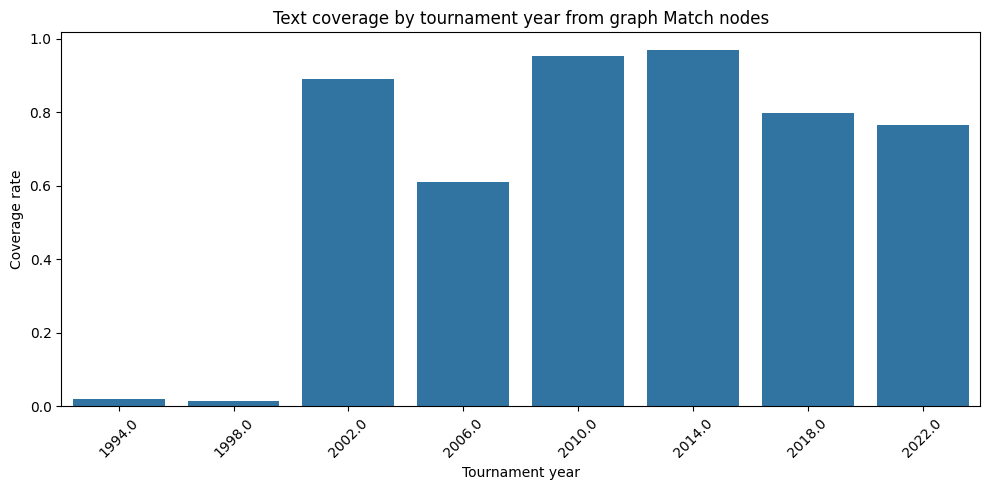

In [38]:
text_cov_graph = (
    match_nodes.groupby("tournament_year")
    .agg(
        matches=("node_id", "count"),
        matches_with_text=("text_available", "sum"),
        avg_text_count=("text_count", "mean"),
    )
    .reset_index()
)

text_cov_graph["coverage_rate"] = (
    text_cov_graph["matches_with_text"] / text_cov_graph["matches"]
)

display(text_cov_graph)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=text_cov_graph,
    x="tournament_year",
    y="coverage_rate",
)
plt.title("Text coverage by tournament year from graph Match nodes")
plt.xlabel("Tournament year")
plt.ylabel("Coverage rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Graph layout с цветом text availability

### Подграф матчей и команд с text availability

In [39]:
def draw_team_match_graph_with_text_status(
    G,
    nodes_df,
    edges_df,
    tournament_year,
    figsize=(18, 14),
    seed=42,
):
    """
    Рисует Team-Match graph, где Match nodes:
    - зеленые, если text_available=1
    - красные, если text_available=0
    """
    H = get_team_match_bipartite_graph(
        G,
        nodes_df,
        edges_df,
        tournament_year=tournament_year,
    )

    node_colors = []
    node_sizes = []
    labels = {}

    for n, data in H.nodes(data=True):
        node_type = data.get("node_type")

        if node_type == "Team":
            node_colors.append("#1f77b4")
            node_sizes.append(600)
            labels[n] = data.get("name", str(n))[:20]

        elif node_type == "Match":
            metadata = parse_metadata_json_safe(data.get("metadata_json"))
            text_available = metadata.get("text_available", 0)

            if text_available == 1:
                node_colors.append("#2ca02c")
            else:
                node_colors.append("#d62728")

            node_sizes.append(160)

        else:
            node_colors.append("#cccccc")
            node_sizes.append(100)

    pos = nx.spring_layout(H, seed=seed, k=0.5)

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        H,
        pos,
        alpha=0.25,
        width=0.8,
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9,
    )

    nx.draw_networkx_labels(
        H,
        pos,
        labels=labels,
        font_size=8,
    )

    plt.title(
        f"Team-Match graph {tournament_year}: "
        f"green match=text available, red=no text"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return H


### Отрисовка text coverage graph для 2022

Team-Match bipartite graph
Tournament: 2022
Nodes: 96
Edges: 323


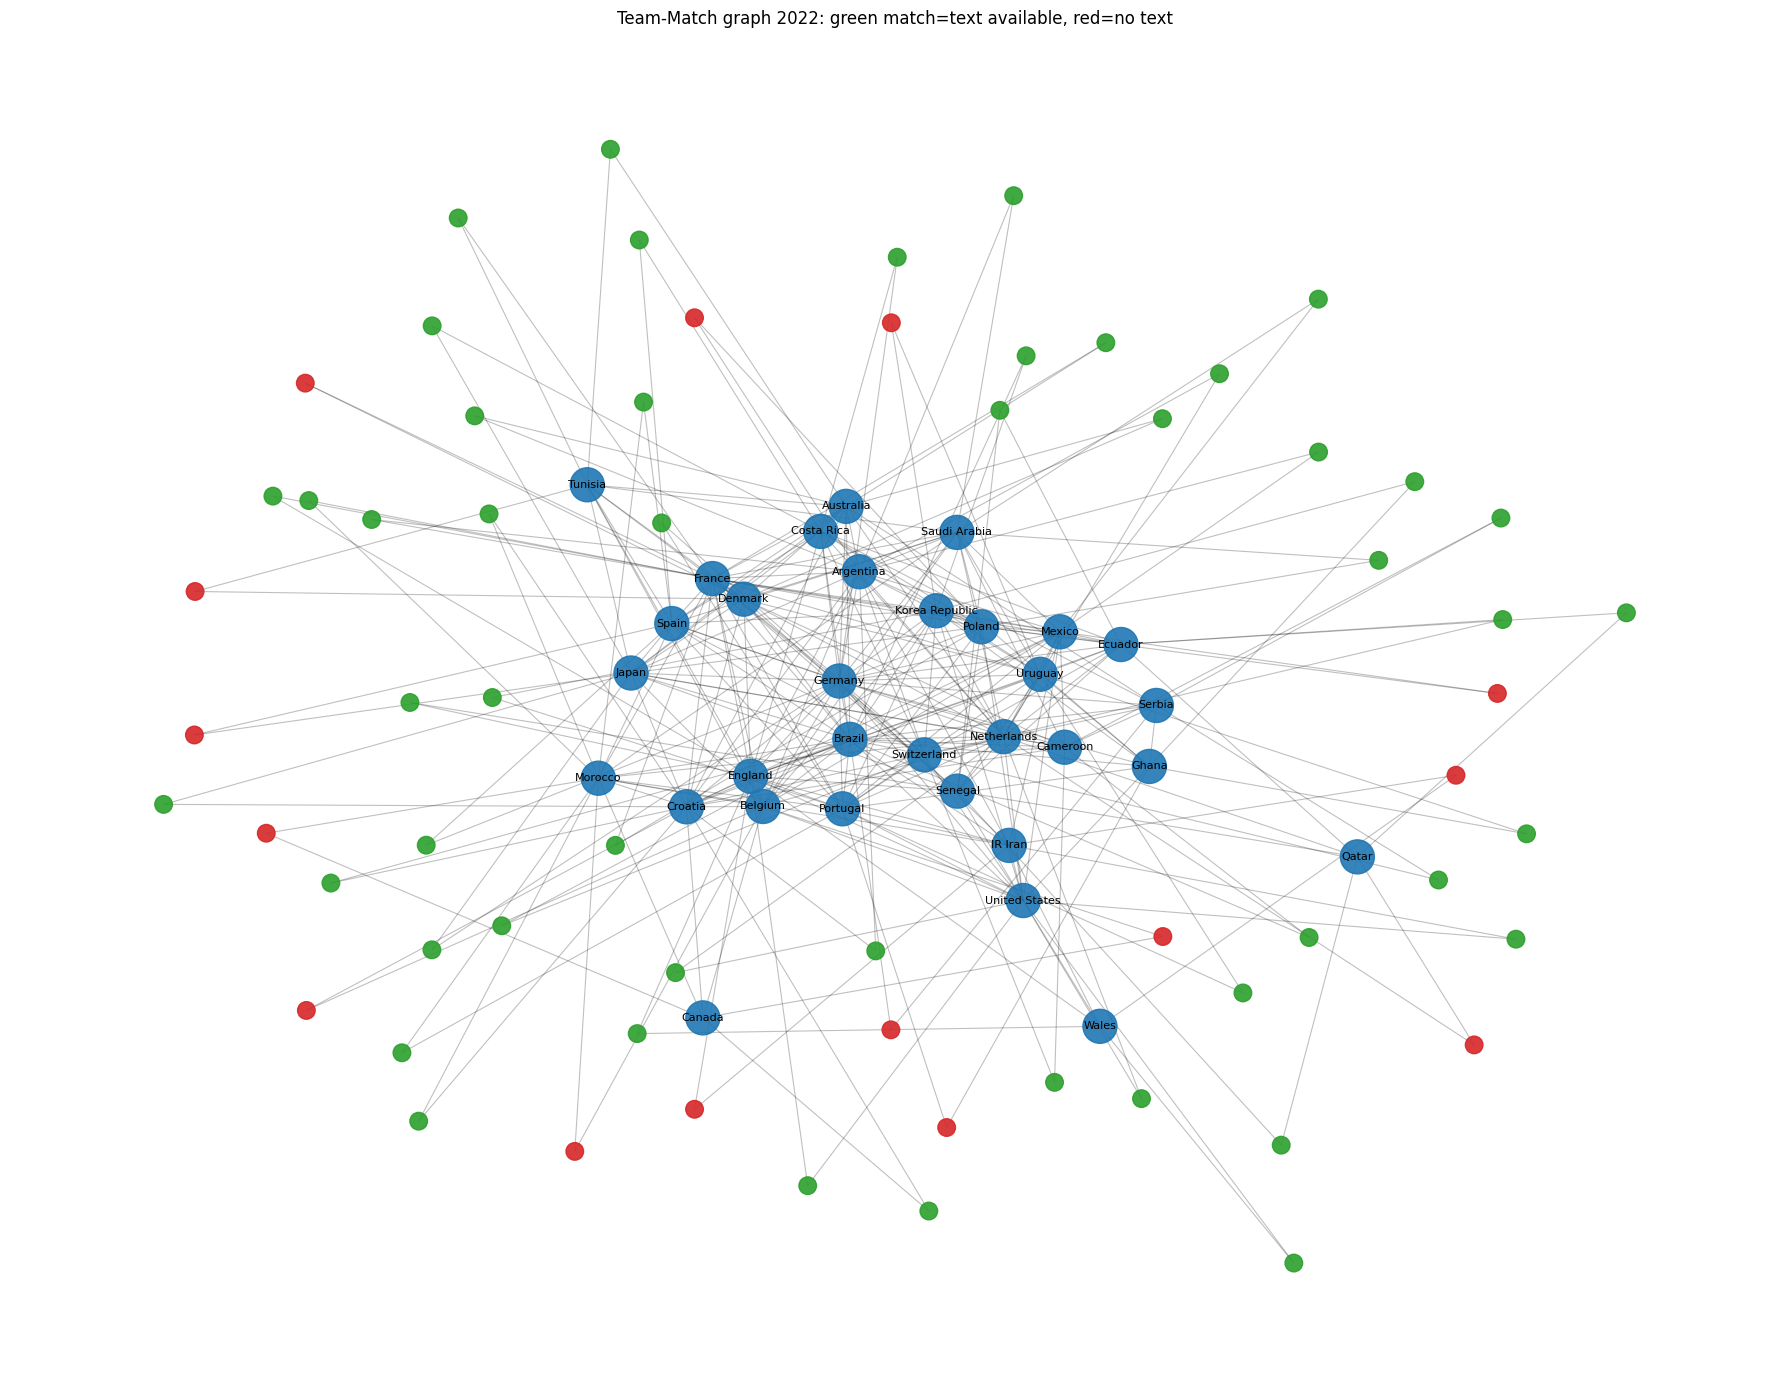

In [40]:
H_text_2022 = draw_team_match_graph_with_text_status(
    G_undirected,
    graph_nodes,
    graph_edges,
    tournament_year=2022,
)
